### **Importation**

In [1]:
# Utilitaires de base
import builtins
import pandas as pd

# Suivi des expriences (MLflow & DagsHub)
import dagshub
import mlflow

# Scikit-Learn : Sparation des donnes et mtriques d'valuation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    f1_score, 
    fbeta_score, 
    precision_score, 
    recall_score
)

# TensorFlow / Keras : Cration et entranement du modle Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization


#### **DagsHub & MLflow Init**

In [2]:
# Initialisation de la connexion DagsHub avec les identifiants de votre dépôt et activation du mode MLflow
# PATCH WINDOWS : Force l'utilisation de l'encodage UTF-8 lors de l'écriture des fichiers.

_original_open = builtins.open
def _utf8_open(*args, **kwargs):
    mode = kwargs.get('mode', args[1] if len(args) > 1 else 'r')
    if 'b' not in mode and 'encoding' not in kwargs:
        kwargs['encoding'] = 'utf-8'
    return _original_open(*args, **kwargs)
builtins.open = _utf8_open

dagshub.init(repo_owner='Oscar-AS', repo_name='disaster-tweets-project', mlflow=True)

# Définition du nom du dossier (expérience) dans MLflow où toutes nos métriques seront classées
mlflow.set_experiment("Disaster_Tweets")

# Affichage d'un message console pour confirmer que le tracking est bien connecté
print("MLflow activé avec succès sur DagsHub !")


Accessing as Oscar-AS

Initialized MLflow to track repo "Oscar-AS/disaster-tweets-project"

Repository Oscar-AS/disaster-tweets-project initialized!

MLflow activé avec succès sur DagsHub !


#### **Importation Données**

In [3]:
#Chargement des données
df = pd.read_csv("Base/tweets.csv")

### **Séparation des données**

In [4]:

# Séparation Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Affiche dans la console le nombre de tweets utilisés pour l'entraînement
print(f"Taille de l'entraînement : {len(X_train)}")
# Affiche dans la console le nombre de tweets gardés pour le test
print(f"Taille du test : {len(X_test)}")


Taille de l'entraînement : 9096
Taille du test : 2274


#### **Implémentation des modèles (Réseaux de Neurones avec TensorFlow/Keras)**

In [5]:
# Définition de la taille maximale du vocabulaire autorisé (les 15000 mots les plus fréquents)
MAX_VOCAB_SIZE = 15000
# Définition de la taille maximale d'une phrase (tronquée si plus longue, remplie par des 0 si plus courte)
MAX_SEQUENCE_LENGTH = 128

# Instanciation de la couche de Vectorisation
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE, # Limite du vocabulaire
    output_mode='int',         # Chaque mot sera remplacé par un nombre entier
    output_sequence_length=MAX_SEQUENCE_LENGTH # Fixe la longueur de toutes les séquences à 128
)

# Apprentissage du vocabulaire : on lit le texte d'entraînement pour créer le dictionnaire mot -> entier
vectorizer.adapt(X_train.to_numpy())

# Fonction utilitaire pour préparer les données afin que TensorFlow s'entraîne plus vite
def prepare_tf_dataset(X, y, batch_size=32):
    # Création d'un dataset TensorFlow à partir de nos listes Python (X et y)
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    # Groupement des données en paquets (batches) de 32, et mise en mémoire cache dynamique (AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    # Retourne le dataset optimisé
    return dataset

# Création du Dataset d'entraînement accéléré
train_ds = prepare_tf_dataset(X_train, y_train)
# Création du Dataset de test accéléré
test_ds = prepare_tf_dataset(X_test, y_test)

# Importation du module MLflow dédié à TensorFlow
# Activation du suivi automatique (enregistrera la loss, les paramètres et les modèles à chaque epoch sans coder manuellement)
mlflow.tensorflow.autolog(log_models=True)


#### **Modèle TextCNN (Convolutional Neural Network 1D)**

##### **Description du modèle**
Historiquement inventé pour l'analyse d'images (pour détecter des bords, des formes), le CNN a été adapté pour le texte (TextCNN) avec un succès retentissant.

##### **Explication du fonctionnement**
Au lieu de lire mot par mot, le CNN utilise des "fenêtres glissantes" (Filtres Convolutifs) qui regardent des groupes de 3, 4 ou 5 mots à la fois. Le modèle cherche spécifiquement des **"motifs" ou "expressions clés"** (ex: "building on fire", "heavy earthquake") indépendamment de leur position dans la phrase.


In [6]:
# Démarrage d'un nouveau Run MLflow nommé "3.2_TextCNN"
with mlflow.start_run(run_name="TextCNN"):
    # Définition de la métrique F2-Score pour Keras
    def f2_score(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())
        return (1 + 4) * (precision * recall) / (4 * precision + recall + tf.keras.backend.epsilon())

    # Création d'un nouveau modèle en couches empilées
    model_cnn = models.Sequential([
        # Couche 1 : Vectorisation (texte vers entiers)
        vectorizer,
        # Couche 2 : Embedding (entiers vers vecteurs mathématiques)
        layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=64),
        # Couche 3 : Convolution 1D, qui utilise 64 filtres et lit des paquets de 5 mots (kernel_size=5) avec une fonction d'activation ReLU
        layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
        # Couche 4 : Regroupement Max Global (ne garde que l'information la plus importante détectée par la convolution)
        layers.GlobalMaxPooling1D(),
        # Couche 5 : Couche dense de 32 neurones pour interpréter l'information
        layers.Dense(32, activation='relu'),
        # Couche 6 : Dropout (désactive aléatoirement 50% des neurones pour éviter le surapprentissage)
        layers.Dropout(0.5),
        # Couche 7 : Prédiction binaire finale (1 neurone, Sigmoid)
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Préparation du modèle avec l'optimiseur adam et suivi de l'accuracy
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_textcnn.keras',
        monitor='val_f2_score',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    model_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', f2_score])
    # Entraînement pendant 3 epochs
    model_cnn.fit(train_ds, validation_data=test_ds, epochs=3, callbacks=[checkpoint_cb])
    
    # Recharger le meilleur modèle
    model_cnn = models.load_model('best_model_textcnn.keras', custom_objects={'f2_score': f2_score})
    
    # Récupération des prédictions formatées en 0 ou 1
    y_pred_cnn = (model_cnn.predict(test_ds) > 0.5).astype(int)
    
    # Affichage dans la console
    print("\n--- Rapport TextCNN ---")
    # Impression du rapport final (F1, Precision, Recall)
    print(classification_report(y_test, y_pred_cnn))
    
    # Suivi explicite des métriques de test dans MLflow
    mlflow.log_metric("eval_f1_macro", f1_score(y_test, y_pred_cnn, average='macro'))
    mlflow.log_metric("eval_f2_score", fbeta_score(y_test, y_pred_cnn, beta=2, average='macro'))
    
    precision_cls = precision_score(y_test, y_pred_cnn, average=None)
    recall_cls = recall_score(y_test, y_pred_cnn, average=None)
    mlflow.log_metric("eval_precision_class_0", precision_cls[0])
    mlflow.log_metric("eval_precision_class_1", precision_cls[1])
    mlflow.log_metric("eval_recall_class_0", recall_cls[0])
    mlflow.log_metric("eval_recall_class_1", recall_cls[1])
    mlflow.log_metric("eval_accuracy", accuracy_score(y_test, y_pred_cnn))
    
    # Enregistrement explicite du modèle pour la mise en production
    try:
        mlflow.tensorflow.log_model(model_cnn, "model")
    except Exception as e:
        print("Erreur lors de la sauvegarde du modèle Keras :", e)


2026/05/07 19:33:08 WARNING mlflow.tensorflow: Encountered unexpected error while inferring batch size from training dataset: Sequential model 'sequential' has no defined input shape yet.
2026/05/07 19:33:10 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xe2 in position 120: ordinal not in range(128)


Epoch 1/3
284/285 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8080 - f2_score: 0.0164 - loss: 0.4991
Epoch 1: val_f2_score improved from None to 0.12272, saving model to best_model_textcnn.keras

Epoch 1: finished saving model to best_model_textcnn.keras


285/285 ━━━━━━━━━━━━━━━━━━━━ 68s 231ms/step - accuracy: 0.8328 - f2_score: 0.0389 - loss: 0.4315 - val_accuracy: 0.8782 - val_f2_score: 0.1227 - val_loss: 0.2995
Epoch 2/3
281/285 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8968 - f2_score: 0.1395 - loss: 0.2696
Epoch 2: val_f2_score improved from 0.12272 to 0.15770, saving model to best_model_textcnn.keras

Epoch 2: finished saving model to best_model_textcnn.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9163 - f2_score: 0.1523 - loss: 0.2247 - val_accuracy: 0.8865 - val_f2_score: 0.1577 - val_loss: 0.3158
Epoch 3/3
284/285 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9621 - f2_score: 0.1742 - loss: 0.1194
Epoch 3: val_f2_score improved from 0.15770 to 0.16111, saving model to best_model_textcnn.keras

Epoch 3: finished saving model to best_model_textcnn.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9677 - f2_score: 0.1776 - loss: 0.1006 - val_accuracy: 0.8821 - val_f2_score: 0.1611 - val_loss: 0

2026/05/07 19:34:33 WARNING mlflow.tensorflow: Failed to infer model signature: Invalid dtype: object
2026/05/07 19:34:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 19:34:37 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/07 19:35:27 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmpo8_ghw19\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


14/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 9 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

--- Rapport TextCNN ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1851
           1       0.72      0.60      0.65       423

    accuracy                           0.88      2274
   macro avg       0.82      0.77      0.79      2274
weighted avg       0.88      0.88      0.88      2274



2026/05/07 19:36:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 19:36:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/07 19:36:45 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmpw_5e_7iu\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


🏃 View run TextCNN at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4/runs/b252cde28f20434289b2f5f20453a0ef
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4


 1/72 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


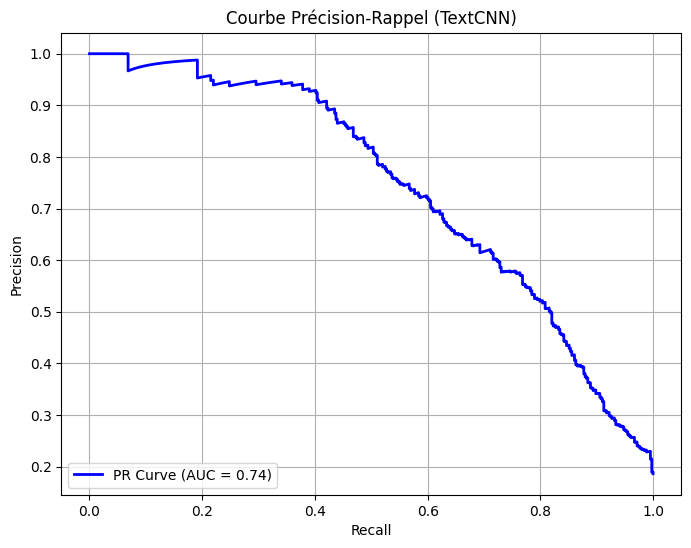

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd

# 1. Calcul des probabilités de prédiction
y_probs = model_cnn.predict(test_ds).ravel()

# 2. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Précision-Rappel (TextCNN)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

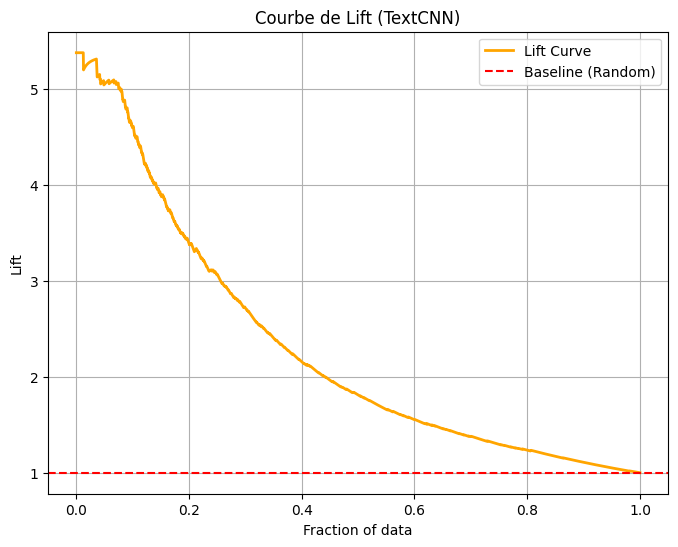

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Courbe de Lift
# Trier les probabilités par ordre décroissant
data = pd.DataFrame({'y_true': y_test, 'y_prob': y_probs})
data = data.sort_values(by='y_prob', ascending=False)
data['cumulative_data_fraction'] = np.arange(1, len(data) + 1) / len(data)
data['cumulative_positive_rate'] = data['y_true'].cumsum() / data['y_true'].sum()
data['lift'] = data['cumulative_positive_rate'] / data['cumulative_data_fraction']

plt.figure(figsize=(8, 6))
plt.plot(data['cumulative_data_fraction'], data['lift'], label='Lift Curve', color='orange', lw=2)
plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Random)')
plt.xlabel('Fraction of data')
plt.ylabel('Lift')
plt.title('Courbe de Lift (TextCNN)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()